In [1]:
# This script uses class definition to store, access and compute GP Observables in an organized manner

import GPKoopman as gpk
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, clear_output
import math

print('Imported PyTorch version:', torch.__version__)
print('Imported NumPy version:', np.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

Imported PyTorch version: 2.5.1+cu124
Imported NumPy version: 2.2.1
True
NVIDIA GeForce RTX 3060 Laptop GPU


### Testing Cells

### Cost Function Definition

In [2]:
# Multi-Trajectory Cost Function Definition

def get_cost_grid(Z, X, Xplus, Xtrain, manager, nT=1, lambda1=1.0, lambda2=1.0, lambda3=1.0):
    """
    Computes the cost function as defined in the Word doc, with different GP Kernel hyperparameters for
    each observable.

    Args:
        Z: Tensor of shape (r**n, p), decision variable, required grad
        X: Tensor of shape (n, nT*N), dataset of N steps from all trajectories
        Xall: Tensor of shape (n, nT*(N+1)), complete training dataset
        Xtrain: Tensor of shape (n, r**n), flattened set of gridpoints for training GPOs
        manager: Object of class GPObservablesManager (manager for all Gaussian Process based Observable functions)
        nT: float, number of trajectories in training dataset
        lambda1: float, Weighting for prediction error minimization term
        lambda2: float, Weightining for Reconstruction Error penalty term
    """
    
    N = (X.shape[1])//nT    # Number of time steps in each trajectory
    p = Z.shape[1]          # Number of Observables
    l = Z.shape[0]//nT      # Decision Horizon
    n = X.shape[0]          # Dimensionality of original system

    for i in range(p):
        manager.train_observable(i, Xtrain, Z[:,i])

    # For current definition of GPOs
    # Training: Xtrain = dimensions x samples
    # Training: Ytrain = samples x (dimensions=1)
    # Prediction: Xquery = dimensions x num-query = Input
    # Prediction: Yquery = num-query x (dimensions=1) = Output

    # Lifting X and Xplus to higher dimension using trained GPOs
    M = torch.empty((p,N*nT))
    Mplus = torch.empty((p,N*nT))
    
    #Mall = torch.empty((p,(N+1)*nT))
    for i in range(p):
        M[i,:] = torch.transpose(manager.predict_mean(i, X), dim0=0, dim1=-1)
        Mplus[i,:] = torch.transpose(manager.predict_mean(i, Xplus), dim0=0, dim1=-1)
    
    # Compute C(z) and A(z)
    Mfull = torch.vstack((X, M))
    Mplusfull = torch.vstack((Xplus, Mplus))

    M_pinv = torch.linalg.pinv(Mfull)
    #Cz = X @ M_pinv
    Az = Mplusfull @ M_pinv
    C = torch.zeros((n,n+p))
    for i in range(n):
        C[i,i] = 1.
    
    # Cost term 1: Multi-Trajectory Prediction Error Minimization
    NormPEM = 0.0
    for j in range(nT):
        TrajPEM = 0.0
        for k in range(N - 1):
            pred_error = X[:, j*N + (k+1)] - C @ (torch.linalg.matrix_power(Az,k+1)) @ Mfull[:,j*N]   # multi-step at X (with Cz)
            TrajPEM += torch.norm(pred_error)
        NormPEM += TrajPEM
    
    # Linearity Enforcement
    NormLEP = 0.0
    for j in range(nT):
        TrajLEP = 0.0
        for k in range(l-1):
            Zk = torch.vstack([X[:, j*N + k].view(n,1), torch.transpose(Z[j*l + k, :], dim0=0, dim1=-1).view(p,1)])
            Zkplus = torch.vstack([X[:, j*N + k + 1].view(n,1), torch.transpose(Z[j*l + k + 1, :], dim0=0, dim1=-1).view(p,1)])
            lin_error = Zkplus - Az @ Zk
            TrajLEP += torch.norm(lin_error)
        NormLEP += TrajLEP
    
    # Weighted sum of terms
    cost = (lambda1 * NormPEM / (N * nT)) + (lambda2 * NormLEP / (l * nT))
    return cost



# Execution Cells

## Data Loading

In [3]:
# Allowed system names -
# "Unforced Duffing"
# "van der Pol"
# "Simple Pendulum"
# "Lorenz"
# "Lotka Volterra"
system_name = 'Unforced Duffing'
data = torch.load(f"Data/DataAuto_{system_name}_right.pt", weights_only=True)

SimData = data["trajectories"] # Shape: (num_trajectories, state_dim, num_steps)
ts = data["sample_time"]
num_trajectories = data["num_trajectories"]
N = data["num_steps"]
nTrain = math.floor(num_trajectories * 0.5)
nTest = math.floor(num_trajectories * 0.2)
SimData = SimData[:,:,:151]
N = 150

## Optimization Section

### Find Optimal Z Values

In [4]:
SimData = SimData.float()
n = SimData.shape[1]

p = 20  # number of lifted states
l = N//10  # decision horizon for each lifted state
r = 10   # resolution along all dimensions

Xall = torch.cat([SimData[j, :, :] for j in range(nTrain)], dim=1)      # Concatenated total matrix
X = torch.cat([SimData[j, :, 0:N] for j in range(nTrain)], dim=1)       # Concatenated Data matrix
Xplus = torch.cat([SimData[j, :, 1:] for j in range(nTrain)], dim=1)    # Time-shifted Data matrix
ICsetTrain = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain)], dim=1)    # Random IC set for training
ICsetTest = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain, nTrain + nTest)], dim=1)  # Random IC set for testing


#X = torch.cat([Xall[:,j*(N+1):j*(N+1)+N] for j in range(nT)],dim=1)         # Data matrix from original system
#Xplus = torch.cat([Xall[:,j*(N+1)+1:j*(N+1)+N+1] for j in range(nT)],dim=1) # Time-shifted data matrix

# Options: 'Horizon' | 'Grid'
trainMethod = 'Horizon'

# Initialize GP training-grid and decision variables
if trainMethod == 'Horizon':
    Xtrain = torch.cat([X[:,j*N:j*N+l] for j in range(nTrain)],dim=1)
    Z = torch.rand(l*nTrain, p, requires_grad=True)
    ObsManager = gpk.GPObservablesManager()
    for i in range(p):
        ObsManager.add_observable(index=i, d=n, ns=l*nTrain, kernel_types=['Gaussian'],noise=1e-6, m=500)
        
elif trainMethod == 'Grid':
    # GPO Training Grid
    gridpoints0 = torch.linspace(-4., 4., steps=r)
    gridpoints1 = torch.linspace(-4., 4., steps=r)
    grid0, grid1 = torch.meshgrid(gridpoints0, gridpoints1, indexing='xy')
    Xtrain = torch.stack([torch.flatten(grid0), torch.flatten(grid1)])
    Z = torch.rand(r**n, p, requires_grad=True)
    ObsManager = gpk.GPObservablesManager()
    for i in range(p):
        ObsManager.add_observable(index=i, d=n, ns=r**n, kernel_types=['Gaussian'],noise=1e-6)

else:
    raise ValueError(f'Unrecognized GP Training method {trainMethod}')


ObsManager.set_random_hyperparameters(scale=1.0)
print('Observable Hyperparameters have been randomized')


Observable Hyperparameters have been randomized


In [5]:
cost = get_cost_grid(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=1., lambda2=1.)

Total Observables available: 20
Starting Iteration Loop!
Iteration 1/200 with 0 Insignificant Iterations
Cost: 5.0455522537231445
Iteration 2/200 with 0 Insignificant Iterations
Cost: 3.8015944957733154
Iteration 3/200 with 0 Insignificant Iterations
Cost: 2.923712730407715
Iteration 4/200 with 0 Insignificant Iterations
Cost: 2.5302088260650635
Iteration 5/200 with 0 Insignificant Iterations
Cost: 2.528055429458618
Iteration 6/200 with 0 Insignificant Iterations
Cost: 2.462358236312866
Iteration 7/200 with 0 Insignificant Iterations
Cost: 2.3647103309631348
Iteration 8/200 with 0 Insignificant Iterations
Cost: 2.283411741256714
Iteration 9/200 with 0 Insignificant Iterations
Cost: 2.218876361846924
Iteration 10/200 with 0 Insignificant Iterations
Cost: 2.162313461303711
Iteration 11/200 with 0 Insignificant Iterations
Cost: 2.102525472640991
Iteration 12/200 with 0 Insignificant Iterations
Cost: 2.0547401905059814
Iteration 13/200 with 0 Insignificant Iterations
Cost: 2.03777146339416

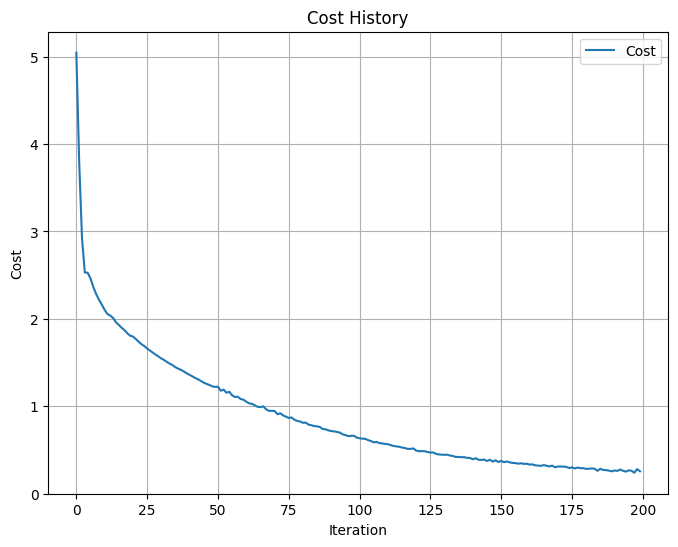

In [6]:
print(f'Total Observables available: {gpk.GPObservable.count_Observables()}')

# Optimization Parameters
max_iter = 200
learn_rate = 0.02   # Learning Rate    
err_thresh = 0.01    # Target Cost
patience = 40       # Number of iterations to monitor for significant change
min_delta = 5e-3    # Minimum required decrease in cost for significance

optimizer = torch.optim.Adam([Z, ObsManager.get_all_params()], lr=learn_rate)    # Optimizer  

print('Starting Iteration Loop!')
cost_history = []
iter = 0
count_insignificant = 0

while iter < max_iter:
    optimizer.zero_grad()  # Clear gradients
    cost = get_cost_grid(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=10.)   # compute cost
    cost_history.append(cost.item())    # add to cost history
    cost.backward(retain_graph=True)    # backpropagate
    optimizer.step()    # gradient descent step

    print(f"Iteration {iter + 1}/{max_iter} with {count_insignificant} Insignificant Iterations")
    print(f"Cost: {cost.item()}")

    # Stopping conditions
    if cost.item() < err_thresh:
        print("Stopping: Error threshold reached.")
        break

    # Check for significant improvement
    if iter > patience:
        error_change = cost_history[-patience] - cost_history[-1]
        if error_change < min_delta or error_change < 0:
            count_insignificant += 1
        else:
            count_insignificant = 0

        if count_insignificant >= patience:
            print("Stopping: No significant improvement over consecutive iterations.")
            break

    # Increment iteration
    iter += 1


if iter == max_iter:
    print(f'Stopping: Reached maximum number of iterations = {iter}.')


optimal_Z = Z.detach()

print('Optimization Complete.')
print("Final Cost:", cost.item())

# Plot cost history
plt.figure(figsize=(8, 6))
plt.plot(cost_history, label="Cost")
plt.title("Cost History")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.grid()
plt.show()


### Post-Process Optimization Results

In [7]:
# Use Optimal Z values to Build GP Models and Optimal A and Z matrices
optimal_Z = Z.detach()
for i in range(p):
    ObsManager.train_observable(i, Xtrain, optimal_Z[:,i])  # train GP Observables with Optimal Z outputs

ObsManager.optimize_hyperparameters()   # Optimize Kernel hyperparameters for Optimal training data

#ObsManager.plot_observables(range_x=(-3,3), range_y=(-3,3))

ObsList = [i for i in range(p)]
A, C = gpk.getKoopman(ObsManager, ObsList, Xall, nTrain, stateAug=True)

## Simulation and Validation

In [8]:
# Evaluation on training set
ZmeanTrain = torch.empty((nTrain, n+p, N))
ZcvTrain = torch.empty((nTrain, n+p, n+p, N))
ZmeanTrain[:, :n, 0] = ICsetTrain.T

XhatTrain = torch.empty((nTrain, n, N))
XcvhatTrain = torch.empty((nTrain, n, n, N))
TrainRMSE = torch.empty((nTrain,n))

for j in range(nTrain): # GP Predict for all training trajectories
    for i in range(p):  # GP predict IC and IC-cv
        ZmeanTrain[j, n+i, 0] = ObsManager.predict_mean(i, ICsetTrain[:, j].view(n,1))
        ZcvTrain[j, n+i, n+i, 0] = ObsManager.predict_covariance(i, ICsetTrain[:, j].view(n,1))
    
    ZmeanTrain[j, :, :], ZcvTrain[j, :, :, :], XhatTrain[j, :, :], XcvhatTrain[j, :, :, :] = gpk.sim_LTI(ZmeanTrain[j,:,0], A, C, num_steps=N, ts=None, x0cv=ZcvTrain[j,:,:,0])
    TrainRMSE[j,:] = torch.sqrt(torch.mean((XhatTrain[j,:,:] - SimData[j,:,:N])**2,1))


# Evaluation on test set
ZmeanTest = torch.empty((nTest, n+p, N))
ZcvTest = torch.empty((nTest, n+p, n+p, N))
ZmeanTest[:, :n, 0] = ICsetTest.T

XhatTest = torch.empty((nTest, n, N))
XcvhatTest = torch.empty((nTest, n, n, N))
TestRMSE = torch.empty((nTest,n))

for j in range(nTest): # GP Predict for all training trajectories
    for i in range(p):  # GP predict IC and IC-cv
        ZmeanTest[j, n+i, 0] = ObsManager.predict_mean(i, ICsetTest[:, j].view(n,1))
        ZcvTest[j, n+i, n+i, 0] = ObsManager.predict_covariance(i, ICsetTest[:, j].view(n,1))

    ZmeanTest[j, :, :], ZcvTest[j, :, :, :], XhatTest[j, :, :], XcvhatTest[j, :, :, :] = gpk.sim_LTI(ZmeanTest[j,:,0], A, C, num_steps=N, ts=None, x0cv=ZcvTest[j,:,:,0])
    TestRMSE[j,:] = torch.sqrt(torch.mean((XhatTest[j,:,:] - SimData[nTest+j,:,:N])**2,1))

XhatTrain, XhatTest, XcvhatTrain, XcvhatTest = XhatTrain.detach(), XhatTest.detach(), XcvhatTrain.detach(), XcvhatTest.detach()

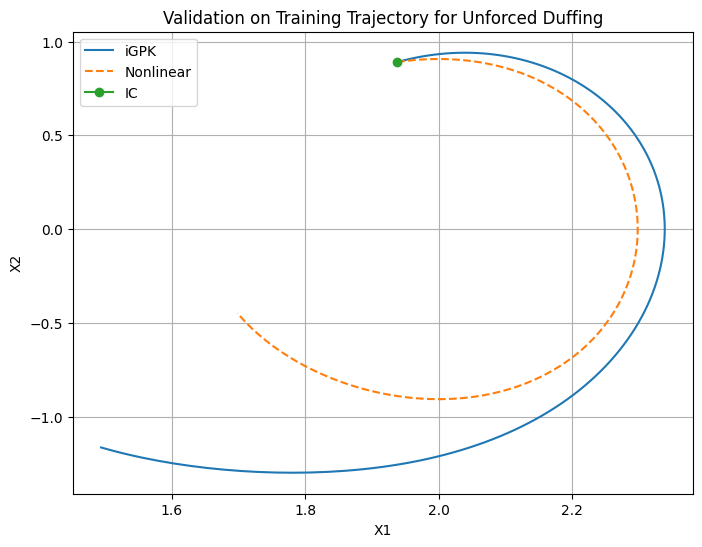

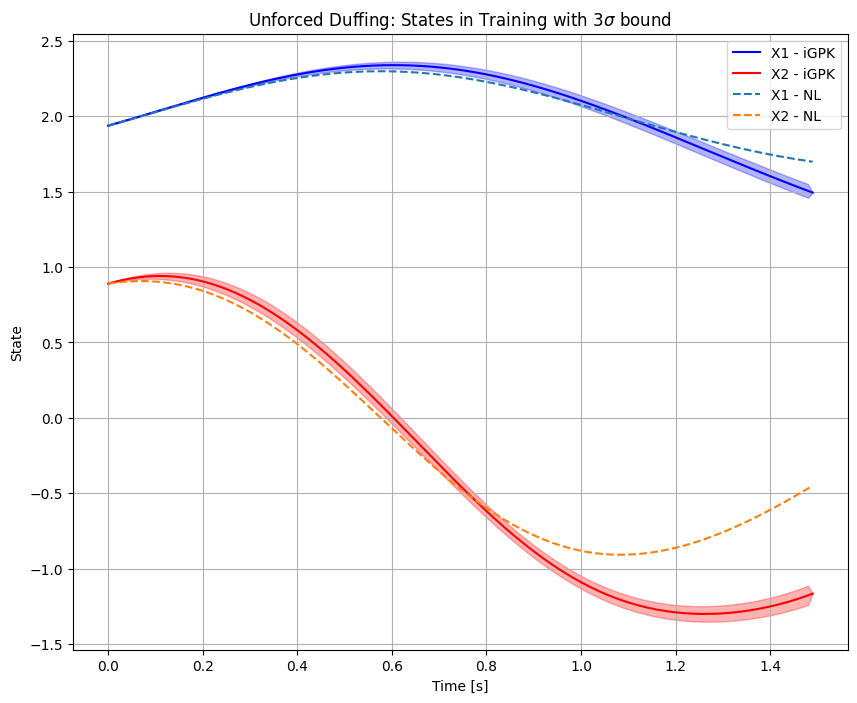

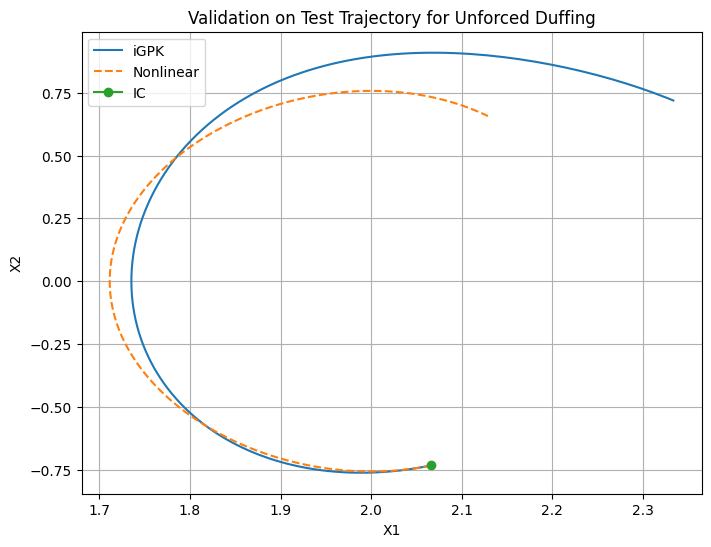

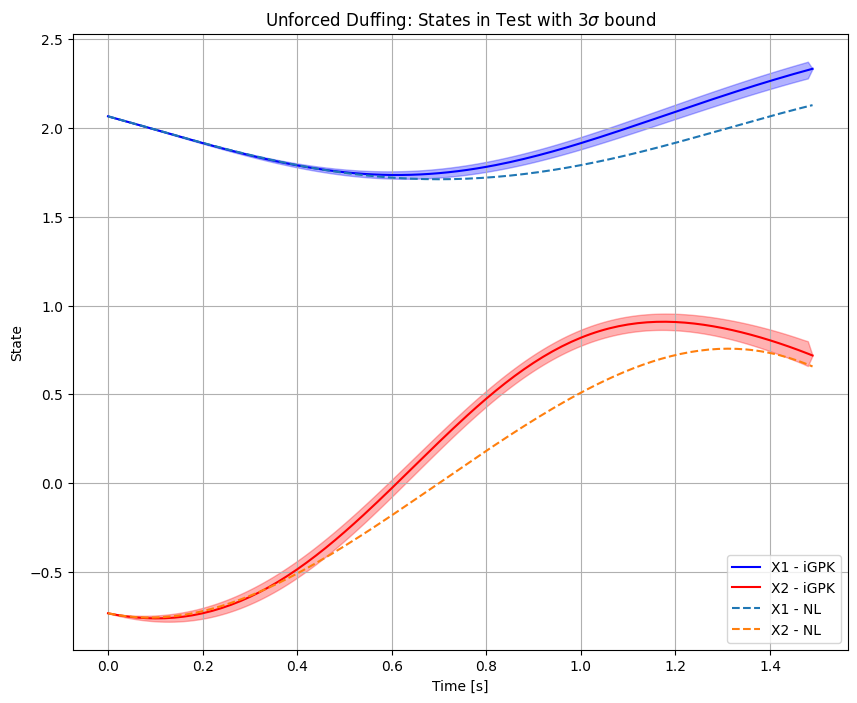

In [9]:
# Function to compute RMSE, NLPD, and sRMSE
def compute_metrics(Xhat, Xcvhat, SimData, nTraj, N, eps=1e-6):
    RMSE = torch.sqrt(torch.mean((Xhat - SimData[:nTraj, :, :N]) ** 2, dim=2))
    
    #var_diag = Xcvhat.diagonal(dim1=1, dim2=2).permute(0, 2, 1)  # Shape (nTraj, n, N)
    
    #NLPD = torch.mean(0.5 * ((SimData[:nTraj, :, :N] - Xhat) ** 2 / var_diag + torch.log(2 * torch.pi * var_diag)), dim=2)
    
    #sRMSE = torch.sqrt(torch.mean(((SimData[:nTraj, :, :N] - Xhat) / var_diag.sqrt()) ** 2, dim=2))

    return RMSE

# Compute metrics for training set
TrainRMSE = compute_metrics(XhatTrain, XcvhatTrain, SimData[:nTrain, :, :], nTrain, N)

# Compute metrics for test set
TestRMSE = compute_metrics(XhatTest, XcvhatTest, SimData[nTrain:(nTrain+nTest), :, :], nTest, N)

time = torch.arange(0., ts * N, ts)
idx1 = torch.argmin(TrainRMSE)
idx2 = torch.argmin(TestRMSE)

# Training Trajectory Phase Plot
plt.figure(1, figsize=(8, 6))
plt.plot(XhatTrain[idx1, 0, :], XhatTrain[idx1, 1, :], label='iGPK')
plt.plot(SimData[idx1, 0, :N], SimData[idx1, 1, :N], label='Nonlinear', linestyle='--')
plt.plot(ICsetTrain[0, idx1], ICsetTrain[1, idx1], label='IC', marker='o')
plt.title(f"Validation on Training Trajectory for {system_name}")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid()
plt.show()

# Training Trajectory Time Plot with uncertainty bound
plt.figure(2, figsize=(10,8))
plt.fill_between(time, XhatTrain[idx1, 0, :] - 3 * XcvhatTrain[idx1, 0, 0, :] ** 0.5, XhatTrain[idx1, 0, :] + 3 * XcvhatTrain[idx1, 0, 0, :] ** 0.5, alpha=0.3, color='blue')
plt.fill_between(time, XhatTrain[idx1, 1, :] - 3 * XcvhatTrain[idx1, 1, 1, :] ** 0.5, XhatTrain[idx1, 1, :] + 3 * XcvhatTrain[idx1, 1, 1, :] ** 0.5, alpha=0.3, color='red')
plt.plot(time, XhatTrain[idx1, 0,:], label='X1 - iGPK', color='blue')
plt.plot(time, XhatTrain[idx1, 1,:], label='X2 - iGPK', color='red')
plt.plot(time, SimData[idx1, 0, :N], label='X1 - NL', linestyle='--')
plt.plot(time, SimData[idx1, 1, :N], label='X2 - NL', linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('State')
plt.title(f'{system_name}: States in Training with 3$\\sigma$ bound')
plt.legend()
plt.grid()
plt.show()


# Test Trajectory Plot
plt.figure(3,figsize=(8, 6))
plt.plot(XhatTest[idx2, 0, :], XhatTest[idx2, 1, :], label='iGPK')
plt.plot(SimData[nTrain+idx2, 0, :N], SimData[nTrain+idx2, 1, :N], label='Nonlinear', linestyle='--')
plt.plot(ICsetTest[0, idx2], ICsetTest[1,idx2], label='IC', marker='o')
plt.title(f"Validation on Test Trajectory for {system_name}")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid()
plt.show()


# Test Trajectory Time Plot with uncertainty bound
plt.figure(4, figsize=(10,8))
plt.fill_between(time, XhatTest[idx2, 0, :] - 3 * XcvhatTest[idx2, 0, 0, :] ** 0.5, XhatTest[idx2, 0, :] + 3 * XcvhatTest[idx2, 0, 0, :] ** 0.5, alpha=0.3, color='blue')
plt.fill_between(time, XhatTest[idx2, 1, :] - 3 * XcvhatTest[idx2, 1, 1, :] ** 0.5, XhatTest[idx2, 1, :] + 3 * XcvhatTest[idx2, 1, 1, :] ** 0.5, alpha=0.3, color='red')
plt.plot(time, XhatTest[idx2, 0,:], label='X1 - iGPK', color='blue')
plt.plot(time, XhatTest[idx2, 1,:], label='X2 - iGPK', color='red')
plt.plot(time, SimData[nTrain+idx2, 0, :N], label='X1 - NL', linestyle='--')
plt.plot(time, SimData[nTrain+idx2, 1, :N], label='X2 - NL', linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('State')
plt.title(f'{system_name}: States in Test with 3$\\sigma$ bound')
plt.legend()
plt.grid()
plt.show()


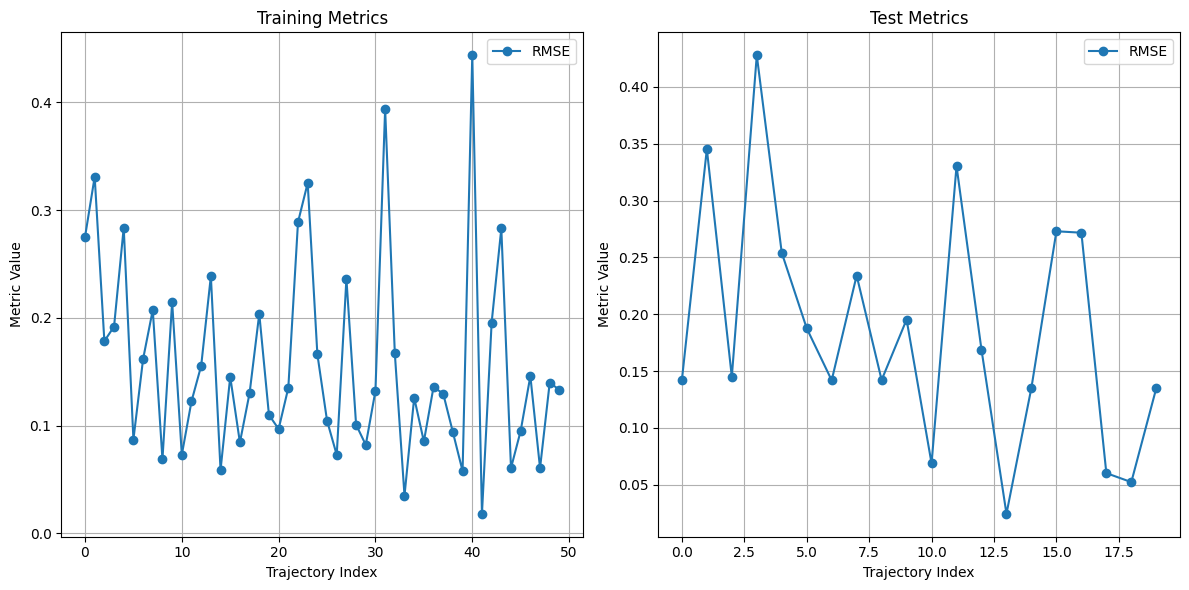

In [10]:
# Plot Errors for all trajectories
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Training set plot
axes[0].plot(range(nTrain), TrainRMSE.mean(dim=1).numpy(), marker='o', linestyle='-', label='RMSE')
#axes[0].plot(range(nTrain), TrainNLPD.mean(dim=1).numpy(), marker='s', linestyle='-', label='NLPD')
#axes[0].plot(range(nTrain), TrainsRMSE.mean(dim=1).numpy(), marker='^', linestyle='-', label='sRMSE')
axes[0].set_title('Training Metrics')
axes[0].set_xlabel("Trajectory Index")
axes[0].set_ylabel("Metric Value")
axes[0].legend()
axes[0].grid()

# Test set plot
axes[1].plot(range(nTest), TestRMSE.mean(dim=1).numpy(), marker='o', linestyle='-', label='RMSE')
#axes[1].plot(range(nTest), TestNLPD.mean(dim=1).numpy(), marker='s', linestyle='-', label='NLPD')
#axes[1].plot(range(nTest), TestsRMSE.mean(dim=1).numpy(), marker='^', linestyle='-', label='sRMSE')
axes[1].set_title('Test Metrics')
axes[1].set_xlabel("Trajectory Index")
axes[1].set_ylabel("Metric Value")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

In [12]:
# Simulate the system
Xq = ICsetTest[:,20].view(n,1)
ValData = gpk.sim_RK4(gpk.f_SDP, Xq[:,0], ts=ts, num_steps=N)

Zmean = torch.empty((p,1))
Zcv = torch.empty((p,1))

for i in range(p):
    Zmean[i,0] = ObsManager.predict_mean(i, Xq)
    Zcv[i,0] = ObsManager.predict_covariance(i, Xq)

Z0 = torch.vstack((Xq, Zmean))
Z0cv = torch.vstack((torch.tensor([[0.], [0.]], device=Zcv.device), Zcv))
Z0cv = torch.diag(Z0cv[:,0])    # vector argument returns a matrix, matrix argument (even shape (n,1)) returns vector shape=(n,)

TrajZ, TrajZcv, Xhat, Xcvhat = gpk.sim_LTI(Z0, A, C, num_steps=N, ts=None, x0cv=Z0cv)

Xhat = Xhat.detach()
Xcvhat = Xcvhat.detach()

# Eigen value plot of Koopman Matrices
eigval = torch.linalg.eigvals(A)

eigreal = eigval.real
eigimag = eigval.imag

eigreal = eigreal.detach().numpy()
eigimag = eigimag.detach().numpy()

theta = np.linspace(0, 2*np.pi, 500)
unitCirclex = np.cos(theta)
unitCircley = np.sin(theta)

plt.figure(2,figsize=(10, 8))
plt.plot(Xhat[0,:], Xhat[1,:], label='GPO-Koopman')
plt.plot(ValData[0,:N], ValData[1, :N], label='Nonlinear', linestyle='--')
plt.plot(Xq[0,0], Xq[1,0], label='IC', marker='o')
plt.title(f"Validation of Optimal GPO-K model for Nonlinear Pendulum")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()
plt.show()

PredRMSE = torch.sqrt(torch.mean((Xhat - ValData[:,:N])**2,1))

print(f'RMS Error for X is: {PredRMSE[0]}')
print(f'RMS Error for Y is: {PredRMSE[1]}')

time = torch.arange(0., ts * N, ts)
plt.figure(3, figsize=(10,8))
plt.fill_between(time, Xhat[0, :] - 3 * Xcvhat[0, 0, :] ** 0.5, Xhat[0, :] + 3 * Xcvhat[0, 0, :] ** 0.5, alpha=0.3, color='blue')
plt.fill_between(time, Xhat[1, :] - 3 * Xcvhat[1, 1, :] ** 0.5, Xhat[1, :] + 3 * Xcvhat[1, 1, :] ** 0.5, alpha=0.3, color='red')
plt.plot(time, Xhat[0,:], label='X1 - GPOK', color='blue')
plt.plot(time, Xhat[1,:], label='X2 - GPOK', color='red')
plt.plot(time, ValData[0,:N], label='X - NL', linestyle='--')
plt.plot(time, ValData[1,:N], label='Y - NL', linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('Position')
plt.title(f'Evolution of System States for {N} steps')
plt.legend()
plt.grid()
plt.show()


IndexError: index 20 is out of bounds for dimension 1 with size 20

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# First subplot: Eigenvalues plot
axes[0].plot(unitCirclex, unitCircley, color='red', label='Unit Circle')
axes[0].scatter(eigreal, eigimag, color='blue', label='Eigenvalues')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].axvline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title(f"Eigenvalues of A Matrix with {p} Observables")
axes[0].set_xlabel("Real Part")
axes[0].set_ylabel("Imaginary Part")
axes[0].grid(True)
axes[0].legend(loc='upper right')

# Second subplot: Heatmap of matrix A
im = axes[1].imshow(A.detach().numpy(), cmap='viridis', aspect='auto')
fig.colorbar(im, ax=axes[1], label="Value")
axes[1].set_title(f'{A.shape[0]}-D Koopman Matrix')
axes[1].set_xlabel("Columns")
axes[1].set_ylabel("Rows")

# Adjust layout for better spacing
plt.tight_layout()

# Show the figure
plt.show()

## Phase Plot of Koopman Linear Model
TrainRMSE = torch.zeros((n,nT))
fig, ax = plt.subplots(figsize=(8, 6))
for j in range(nT):  # Loop over different initial conditions
    x0 = randIC[:, j].view(n,1)  # Select one initial condition
    Z0ph = torch.zeros((p,1))
    for i in range(p):
        Z0ph[i,0] = ObsManager.predict_mean(i, x0)
    Z0ph = torch.vstack((x0, Z0ph))
    phstates, phoutputs = gpk.sim_LTI(Z0ph, A, C, num_steps=N, ts=None)  # Simulate system
    TrainRMSE[:,j] = torch.sqrt(torch.mean((X[:, j*N : (j+1)*N] - phoutputs)**2,1))
    # Plot phase trajectory (assuming a 2D phase space: first two states)
    ax.plot(phoutputs.detach().numpy()[0, :], phoutputs.detach().numpy()[1, :], alpha=0.6, color='blue')

# Configure plot
ax.set_title("Phase Plot of Koopman Linear System")
ax.set_xlabel("X1: Theta")
ax.set_ylabel("X2: Omega")
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax.grid(True)

plt.show()




In [ ]:
plt.plot(TrainRMSE.detach().numpy()[0,:], color='blue', label='X1', alpha=0.5)
plt.plot(TrainRMSE.detach().numpy()[1,:], color='red', label='X2', alpha=0.5)
plt.xlabel('Trajectory')
plt.ylabel('RMSE')
plt.title(f'Koopman Linear Model RMSE for {nT} Training Trajectories')
plt.legend()
plt.grid()
plt.show()

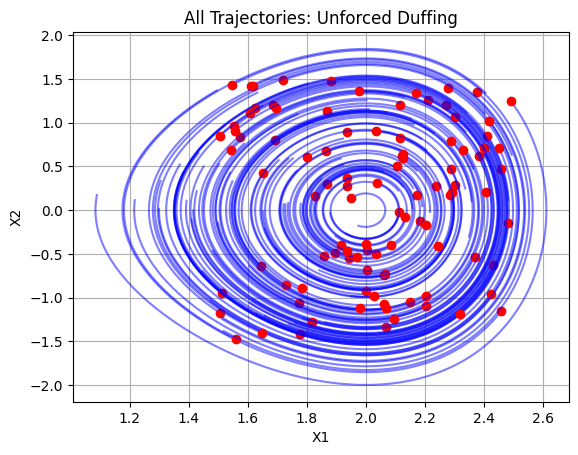

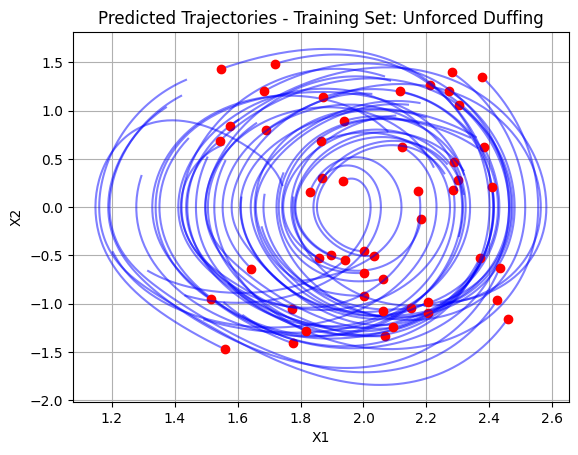

In [11]:
for j in range(SimData.shape[0]):
    plt.plot(SimData[j,0,:], SimData[j,1,:], alpha=0.5, color='blue')
    plt.plot(SimData[j,0,0], SimData[j,1,0], 'o', color='red')

plt.grid()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'All Trajectories: {system_name}')
plt.show()

# Training Set Predicted Trajectories
for j in range(XhatTrain.shape[0]):
    plt.plot(XhatTrain[j,0,:], XhatTrain[j,1,:], alpha=0.5, color='blue')
    plt.plot(XhatTrain[j,0,0], XhatTrain[j,1,0], 'o', color='red')

plt.grid()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'Predicted Trajectories - Training Set: {system_name}')
plt.show()
